This notebook tests basic simulation by recapitulating a simulated dataset several times and measuring variance.

Imports

In [1]:
import sys
import os
import scMPRAforge as scm
import pandas as pd
import numpy as np

2025-07-26 16:25:55.752127: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-26 16:25:56.699559: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-07-26 16:25:56.699581: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

cluster=SLURMCluster(
    cores=4,#cores per slurm job
    memory="16G",#memory per slurm job
    processes=16,#dask workers
    job_extra_directives=["-p ycga", 
        f"--job-name=simclust_worker",
        f"--time=4:00:00",
        f"--output=slave_%j.out"]
)

cluster.scale(jobs=4)

client = Client(cluster,
        timeout=f"{5*60}s",   # Client <-> scheduler timeout 
        heartbeat_interval="20s"  # Worker heartbeat interval
    )

2025-07-23 20:28:08,404 - distributed.scheduler - ERROR - Task _smart_matrix-82eb8ea6bce6c11d90ee6f69e8cfc702 marked as failed because 4 workers died while trying to run it
2025-07-23 20:28:08,491 - distributed.scheduler - ERROR - Task _smart_matrix-ee5ab34a6e2226ecb20b46ffd5468b5e marked as failed because 4 workers died while trying to run it
2025-07-23 20:28:08,497 - distributed.scheduler - ERROR - Task _smart_matrix-a0387594ae737db3d7b4a40d77bc3282 marked as failed because 4 workers died while trying to run it
2025-07-23 20:28:08,504 - distributed.scheduler - ERROR - Task _smart_matrix-e96e1c5ae3208874906b4fe9c2288c0b marked as failed because 4 workers died while trying to run it
2025-07-23 20:28:08,512 - distributed.scheduler - ERROR - Task _smart_matrix-6ecdcc0273c744f94320a6c5ad2e2bc5 marked as failed because 4 workers died while trying to run it


Make the dask cluster & client in accordance with resource avail and model size

In [4]:
dat=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres_v3.tsv")
dat.ortho_filter()
dat.set_negative_controls(["nobody","weak"])
dat.set_reference_cell("liver")

scMPRAforge: INFO: Dropped 0 of 27 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [5]:
#let's make an ortho object out of the data on disc, we'll call 'primordial'
primordial=scm.ortho()
primordial.criss_cross(client=client,dat=dat)
primordial.extract_params(client)

In [6]:
batch=scm.simulation_batch(primordial)
batch.describe_primordial()

In [7]:
batch.simulate_many(client,3)

In [8]:
batch.fit_to_simulations(client)

In [9]:
batch._flatten_all_parameters()

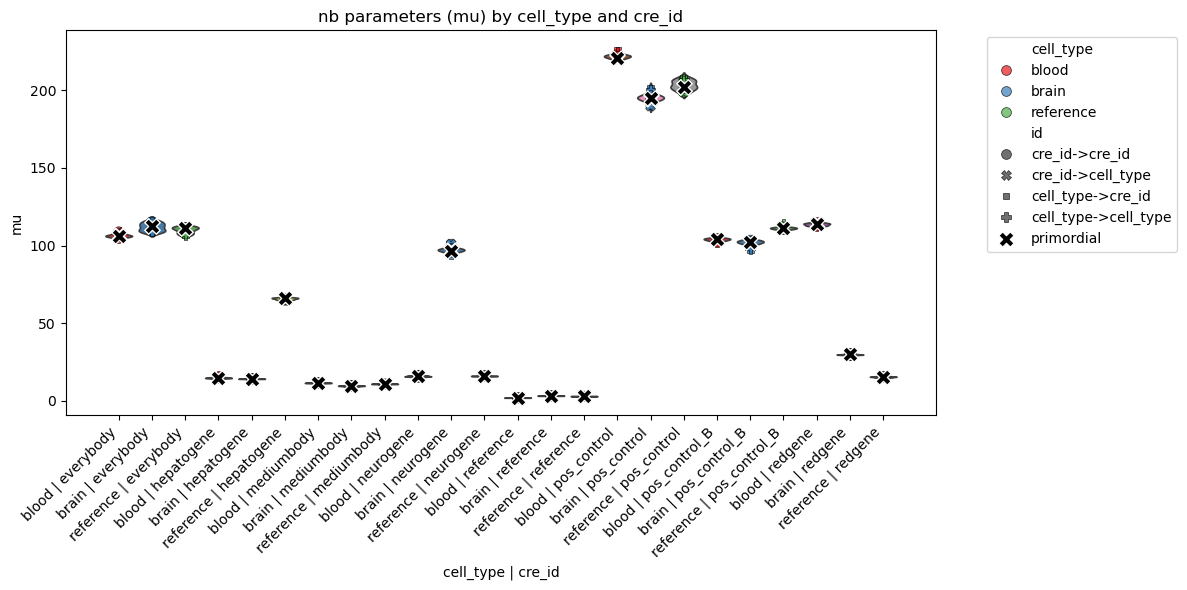

In [12]:
batch.plot_nb_spread()

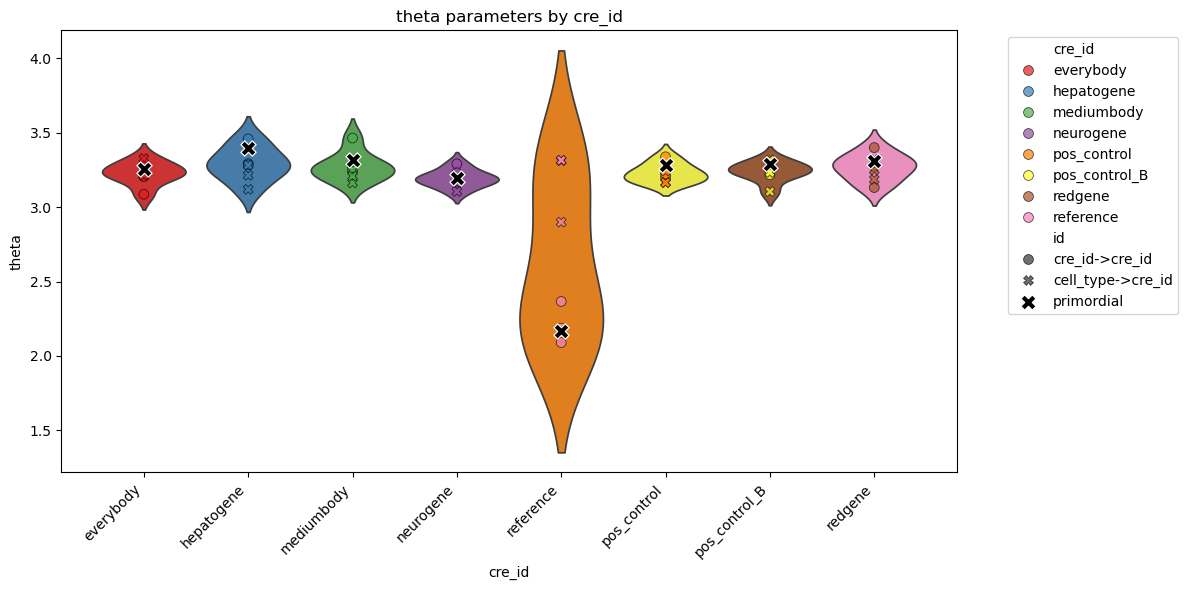

In [13]:
batch.plot_theta_spread("cre_id")

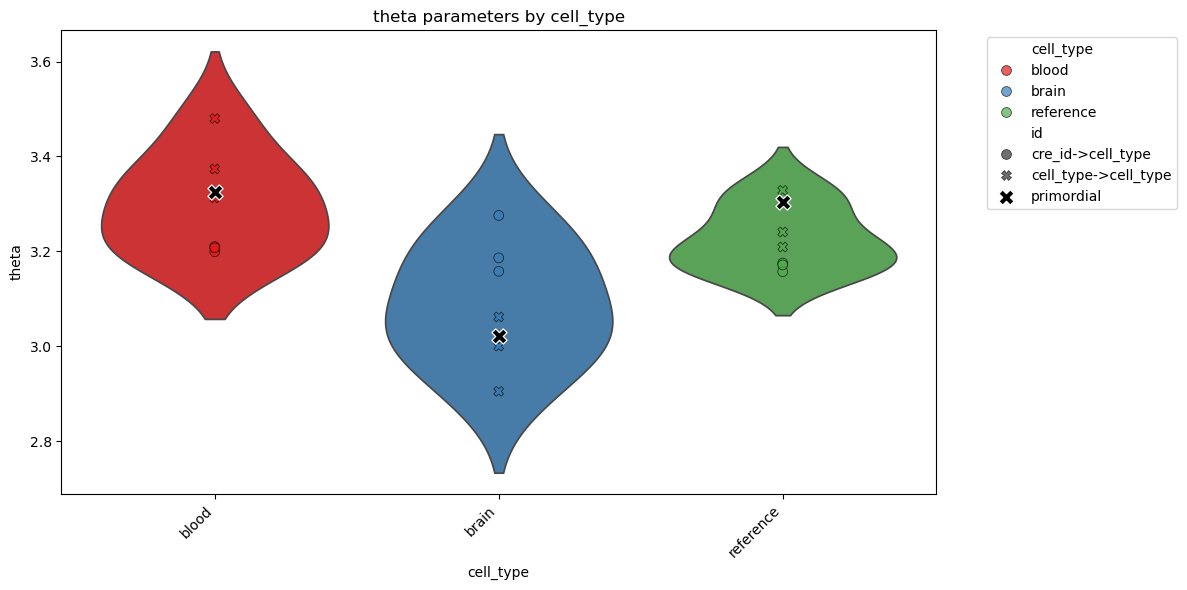

In [14]:
batch.plot_theta_spread("cell_type")

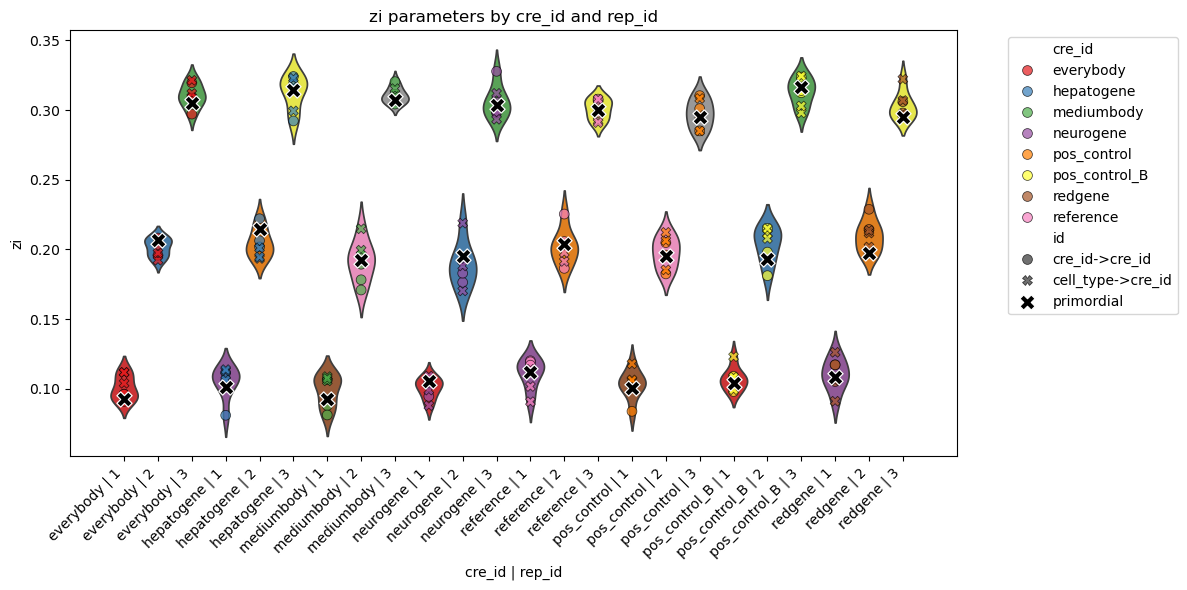

In [15]:
batch.plot_zi_spread("cre_id")

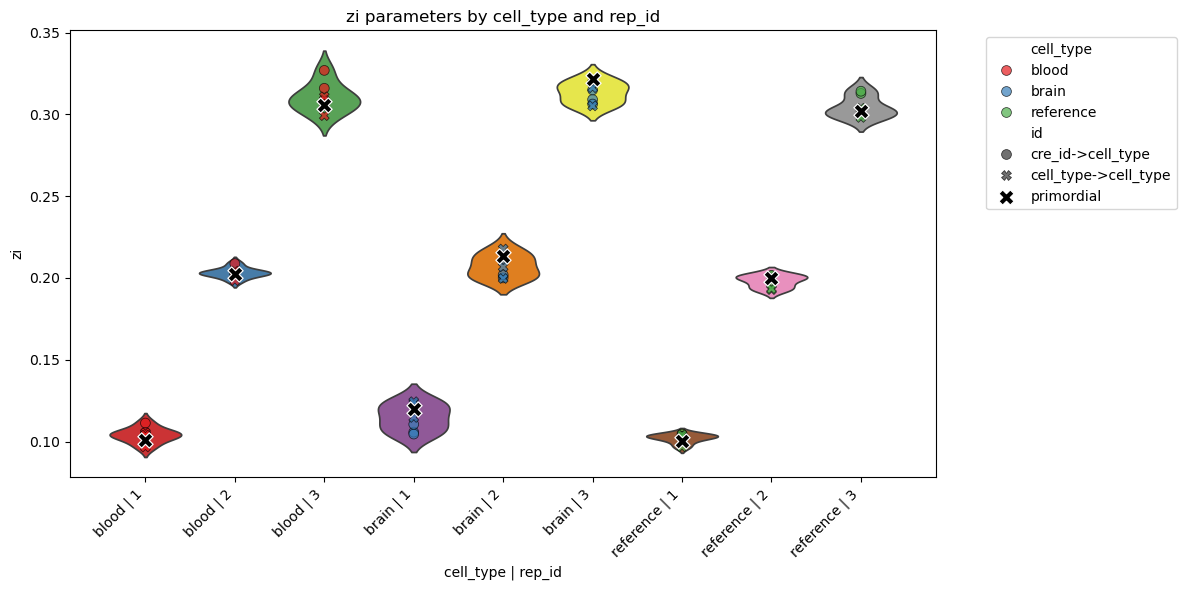

In [16]:
batch.plot_zi_spread("cell_type")

In [17]:
cluster.close()